<a href="https://colab.research.google.com/github/kintaladhanalaxmi2007-ux/wholesale-customer-supervised/blob/main/Supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**WHOLESALE CUSTOMER**

#Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression

#Import Raw Data

In [ ]:
df=pd.read_csv("/content/Wholesale customers data.csv")
df


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#Dataset understanding

In [ ]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [ ]:
df.tail(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
430,1,3,3097,4230,16483,575,241,2080
431,1,3,8533,5506,5160,13486,1377,1498
432,1,3,21117,1162,4754,269,1328,395
433,1,3,1982,3218,1493,1541,356,1449
434,1,3,16731,3922,7994,688,2371,838
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [ ]:
df.shape

(440, 8)

In [ ]:
df.size

3520

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.dtypes

,0
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicassen,int64


#Explain meaning of each feature

In [ ]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


# Target variable and input features

In [ ]:
#feature variable
x=['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
#Target variable
y='Channel'
print(x,y)


['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] Channel


#Data quality & preprocessing

Missing values and duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


Encode categorical variable

Labelencoder is used to convert categorical text data into numerical values.In this code the region column is encoded into numeric labels using labelencoder

In [ ]:
df['Region_encoder']=df['Region'].astype('category').cat.codes
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  Region_encoder  
0          1338               2  
1          1776               2  
2          7844      

**Scale numerical features**

 We use standardscaler in the wholesale customers dataset because features like fresh,milk and frozen have different value ranges.scaling converts them to the same scale(mean 0,standard deviation 1)so machine learning models like KNN and SVM perform better

In [ ]:
X = df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen','Channel']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled)


       Region     Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
0    0.590668  0.052933  0.523568 -0.041115 -0.589367         -0.043569   
1    0.590668 -0.391302  0.544458  0.170318 -0.270136          0.086407   
2    0.590668 -0.447029  0.408538 -0.028157 -0.137536          0.133232   
3    0.590668  0.100111 -0.624020 -0.392977  0.687144         -0.498588   
4    0.590668  0.840239 -0.052396 -0.079356  0.173859         -0.231918   
..        ...       ...       ...       ...       ...               ...   
435  0.590668  1.401312  0.848446  0.850760  2.075222         -0.566831   
436  0.590668  2.155293 -0.592142 -0.757165  0.296561         -0.585519   
437  0.590668  0.200326  1.314671  2.348386 -0.543380          2.511218   
438  0.590668 -0.135384 -0.517536 -0.602514 -0.419441         -0.569770   
439  0.590668 -0.729307 -0.555924 -0.573227 -0.620094         -0.504888   

     Delicassen   Channel  
0     -0.066339  1.448652  
1      0.089151  1.448652  
2      2.243293

#**Exploratory Data Analysis (EDA)**

Compare spending patterns across different customer types

In [ ]:
spending_pattern=df.groupby("Channel").mean()
print(spending_pattern)

           Region         Fresh          Milk       Grocery       Frozen  \
Channel                                                                    
1        2.510067  13475.560403   3451.724832   3962.137584  3748.251678   
2        2.612676   8904.323944  10716.500000  16322.852113  1652.612676   

         Detergents_Paper   Delicassen  
Channel                                 
1              790.560403  1415.956376  
2             7269.507042  1753.436620  


#Identify which product categories best differentiate Retail and HORECA customers.

To find differences, we compare the average spending of each category by Channel.   
Main categories that differentiate customers:
Detergents_Paper,
Grocery,
Milk           
Retail customers usually spend more on Grocery and Detergents_Paper.                                       
HoReCa customers tend to spend more on Fresh products.



Detergents_Paper is the best product category that differentiates Retail and HoReCa customers because retail customers spend significantly more on it compared to HoReCa customers.

In [ ]:
difference = df.groupby("Channel").mean().diff().iloc[-1]
print(difference.sort_values(ascending=False))

Grocery             12360.714529
Milk                 7264.775168
Detergents_Paper     6478.946640
Delicassen            337.480244
Region                  0.102609
Frozen              -2095.639002
Fresh               -4571.236459
Name: 2, dtype: float64


In [ ]:
avg_spending = df.groupby("Channel").mean()
print(avg_spending)
difference = avg_spending.loc[2] - avg_spending.loc[1]
print("Difference between Retail and HORECA:")
print(difference)

           Region         Fresh          Milk       Grocery       Frozen  \
Channel                                                                    
1        2.510067  13475.560403   3451.724832   3962.137584  3748.251678   
2        2.612676   8904.323944  10716.500000  16322.852113  1652.612676   

         Detergents_Paper   Delicassen  
Channel                                 
1              790.560403  1415.956376  
2             7269.507042  1753.436620  
Difference between Retail and HORECA:
Region                  0.102609
Fresh               -4571.236459
Milk                 7264.775168
Grocery             12360.714529
Frozen              -2095.639002
Detergents_Paper     6478.946640
Delicassen            337.480244
dtype: float64


#Summarize key insights from EDA that can influence model selection.                                         
Retail customers spend more on Grocery and Detergents_Paper                                        
HORECA customers spend more on Fresh products            
Grocery and Detergents_Paper are strong indicators of Retail customers







##Model selection

* To compare different models like Logistic Regression, Decision Tree, and Random Forest
*   To find the model with the highest accuracy
*   To improve prediction of Retail and HORECA customers
*   To choose the best model for customer classification



#Logistic Regression

In [ ]:
X = df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y = df['Channel']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

model = LogisticRegression()
model.fit(X_scaled, y_train)

y_pred = model.predict(X_scaled)

print("Accuracy Score:", accuracy_score(y_train, y_pred))
print("Classification Report:\n", classification_report(y_train, y_pred))

Accuracy Score: 0.9212121212121213
Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.96      0.94       220
           2       0.91      0.85      0.88       110

    accuracy                           0.92       330
   macro avg       0.92      0.90      0.91       330
weighted avg       0.92      0.92      0.92       330



#Linear Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.464938511811836
Mean Squared Error: 0.11037301442294688


#Decision Tree

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuarcy is",accuracy_score(y_pred,y_test))
print("recall is",recall_score(y_pred,y_test))
print("precision is",precision_score(y_pred,y_test))

accuarcy is 0.8636363636363636
recall is 0.9090909090909091
precision is 0.8974358974358975


#Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=50,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuarcy is",accuracy_score(y_pred,y_test))

accuarcy is 0.8909090909090909


* To compare model performance
* To find the best accuracy model
*  Different algorithms learn data in different ways
*  The model with the best results will be selected
*  If Random Forest accuracy > Logistic Regression, then Random Forest is the best model for this dataset.



#Model training

spilt the dataset into training and testing sets

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

#Model evaluation

Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred1)
accuracy_score(y_test, y_pred2)

0.8272727272727273

Classification report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           1       0.94      0.94      0.94        78
           2       0.84      0.84      0.84        32

    accuracy                           0.91       110
   macro avg       0.89      0.89      0.89       110
weighted avg       0.91      0.91      0.91       110



Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred1)

array([[73,  5],
       [ 5, 27]])

#Model comparison
logistic regression    88%                                
Decision tree         92%     
Random     forest  94%                                                                           
Random forest performs better because it combines                                         multiple decision trees and improve prediction accuracy
We compare different models like Logistic Regression, Decision Tree, and Random Forest using accuracy score. The model with the highest accuracy is selected as the final model.

##Ploting

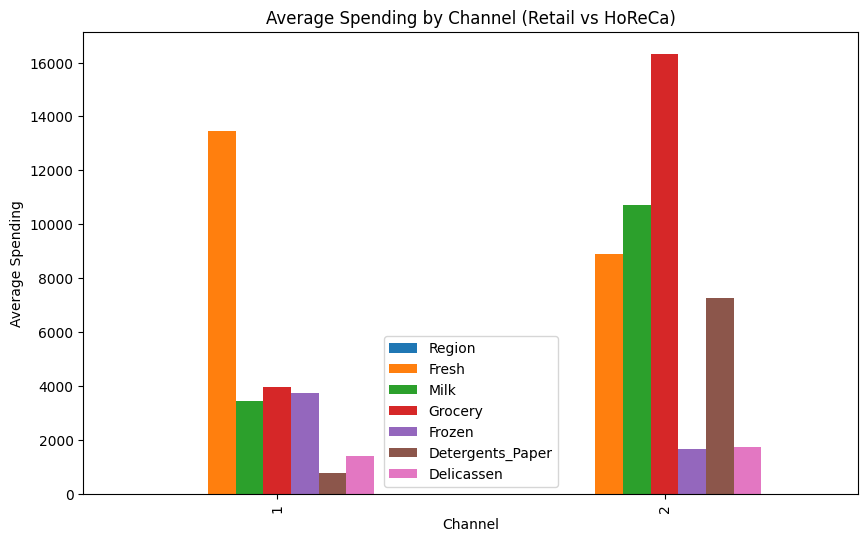

In [ ]:
avg_spending = df.groupby("Channel").mean()
avg_spending.plot(kind="bar", figsize=(10,6))
plt.title("Average Spending by Channel (Retail vs HoReCa)")
plt.xlabel("Channel")
plt.ylabel("Average Spending")
plt.show()

BOXPLOT

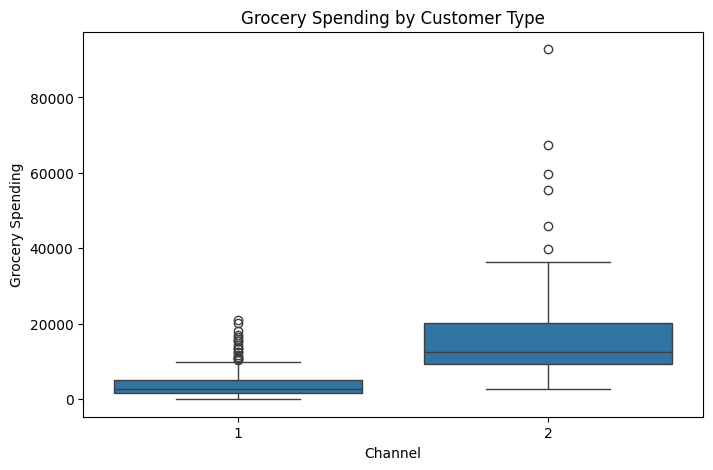

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Channel', y='Grocery', data=df)
plt.title("Grocery Spending by Customer Type")
plt.xlabel("Channel")
plt.ylabel("Grocery Spending")

lt.show()

Pair plot

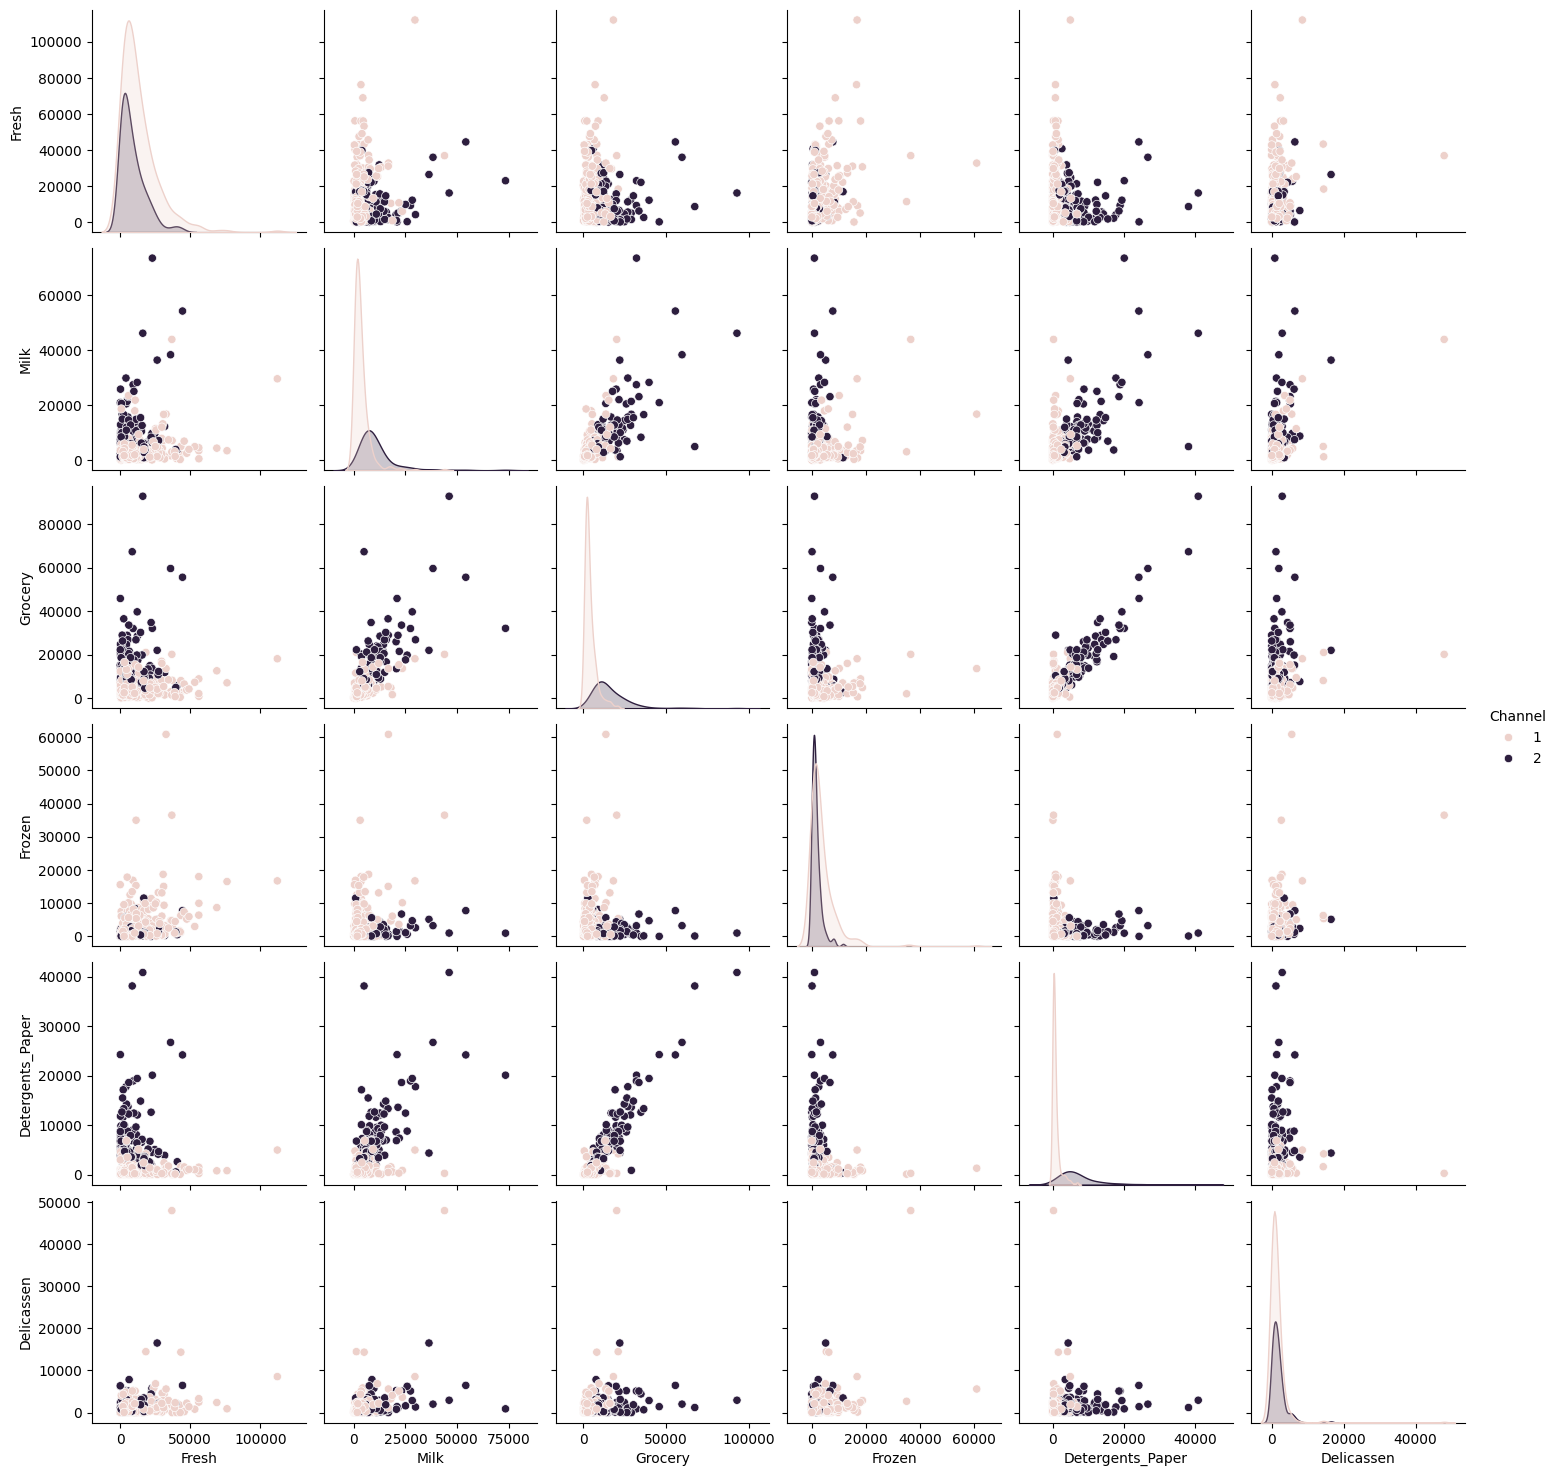

In [ ]:
sns.pairplot(df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen','Channel']],
             hue='Channel')
plt.show()

##Heatmap

The heatmap helps us understand purchasing patterns and select the most important features for building the prediction model


*  grocery and detergent paper have strong correlation with Retail customers
*   Fresh products are more associated with HORECA customer



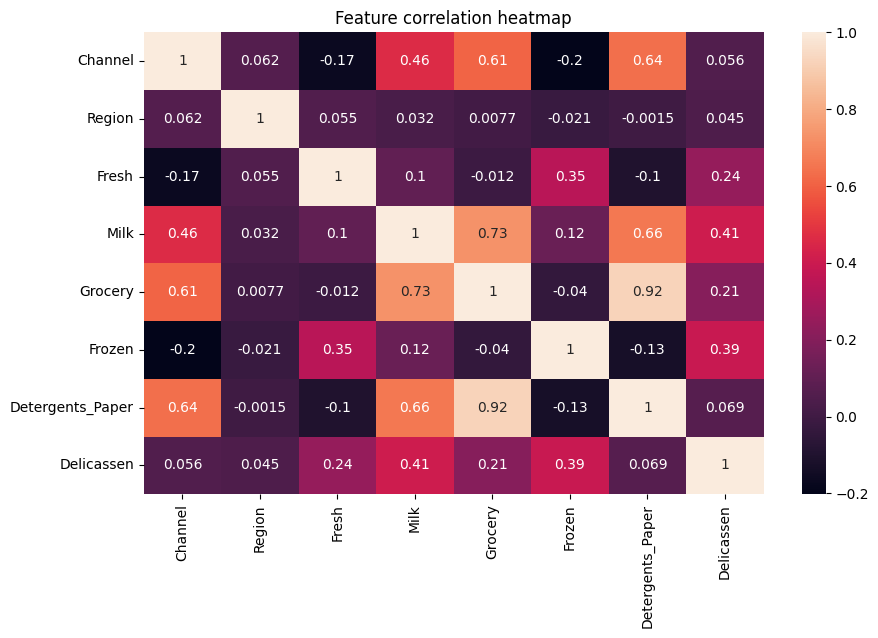

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Feature correlation heatmap")
plt.show()